# Step 7 — CMIP6 water-pathway regime scatterplots

**English.** This notebook uses only CMIP6 variables to describe whether each 1985–2014 non-ice land grid cell is evapotranspiration-dominated or runoff-dominated. It performs scatterplot EDA before fitting any tree.

**中文。** 本 notebook 只使用 CMIP6 变量，描述每个 1985–2014 无冰陆地网格长期属于蒸散主导还是径流主导。在训练 tree 之前，先用散点图检查类别与各变量及变量组合之间的关系。

## 1. Regime definition / 状态定义

The classification is defined directly from the two CMIP6 fluxes:

- **ET-dominated:** $ET>R$
- **Runoff-dominated:** $R\ge ET$

For visualization, the continuous partition contrast is

$$D=ET-R.$$

Positive $D$ indicates ET dominance and negative $D$ indicates runoff dominance. This retains the magnitude information that would be lost by plotting a binary 0/1 outcome.

分类直接由两个 CMIP6 通量定义：$ET>R$ 为蒸散主导，$R\ge ET$ 为径流主导。散点图纵轴使用连续差值 $D=ET-R$；正值代表蒸散主导，负值代表径流主导。这样比把二元类别画成 0/1 两条水平线包含更多信息。

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="ticks", context="notebook")
plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 220,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "DejaVu Sans", "axes.edgecolor": "#30343B",
    "axes.linewidth": 0.9, "axes.titlesize": 11,
    "axes.titleweight": "semibold", "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
})

REGIME_ORDER = ["ET-dominated", "Runoff-dominated"]
REGIME_COLORS = {"ET-dominated": "#D97706", "Runoff-dominated": "#2563A6"}

def find_case_dir(start=Path.cwd()):
    start = start.resolve()
    for base in (start, *start.parents):
        if base.name.lower() == "casea":
            return base
        candidate = base / "case" / "caseA"
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not locate case/caseA.")

def style_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#30343B")
        spine.set_linewidth(0.9)
    ax.tick_params(direction="out", length=3.5, width=0.75, color="#30343B")
    ax.grid(True, color="#D3D3D3", linewidth=0.8, alpha=0.80, zorder=0)

CASE_DIR = find_case_dir()
DERIVED_DIR = CASE_DIR / "derived"
FIGURE_DIR = DERIVED_DIR / "figures_step7"
INPUT_TABLE = DERIVED_DIR / "MPI_ESM1_2_LR_climate_driver_grid_1985_2014.parquet"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
if not INPUT_TABLE.exists():
    raise FileNotFoundError(INPUT_TABLE)
print(f"Input: {INPUT_TABLE}")

Input: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/MPI_ESM1_2_LR_climate_driver_grid_1985_2014.parquet


In [2]:
data = pd.read_parquet(INPUT_TABLE).copy()
data["partition_contrast"] = data["ET"] - data["R"]
data["regime"] = np.where(data["partition_contrast"] > 0, "ET-dominated", "Runoff-dominated")
data["regime"] = pd.Categorical(data["regime"], categories=REGIME_ORDER, ordered=True)
data["log1p_snw"] = np.log10(1 + data["snw"].clip(lower=0))

summary = data.groupby("regime", observed=True).agg(
    n_cells=("grid_id_numeric", "size"),
    land_area_m2=("land_area", "sum"),
    median_ET_minus_R=("partition_contrast", "median"),
).reset_index()
summary["cell_share"] = summary["n_cells"] / summary["n_cells"].sum()
summary["land_area_share"] = summary["land_area_m2"] / summary["land_area_m2"].sum()
display(summary)

OUTPUT_TABLE = DERIVED_DIR / "MPI_ESM1_2_LR_water_pathway_regimes_1985_2014.parquet"
data.to_parquet(OUTPUT_TABLE, index=False)
print(f"Saved: {OUTPUT_TABLE}")

,regime,n_cells,land_area_m2,median_ET_minus_R,cell_share,land_area_share
0,ET-dominated,3440,1.167505e+14,341.496460,0.824545,0.888956
1,Runoff-dominated,732,1.458387e+13,-104.689384,0.175455,0.111044


Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/MPI_ESM1_2_LR_water_pathway_regimes_1985_2014.parquet


## 2. One predictor at a time / 分别查看六个输入变量

**English.** Every point is one CMIP6 non-ice land grid cell. Color is the categorical output, while the vertical axis preserves the continuous difference $ET-R$. The solid horizontal line at zero is the exact classification boundary. The white-edged dark curve connects medians in predictor quantile bins and is only a descriptive guide.

**中文。** 每个点代表一个 CMIP6 无冰陆地网格。颜色表示分类输出，纵轴保留连续的 $ET-R$。零值实线是严格的分类边界。带白色边缘的深色曲线连接解释变量分位数分箱后的中位数，只用于描述总体形状。

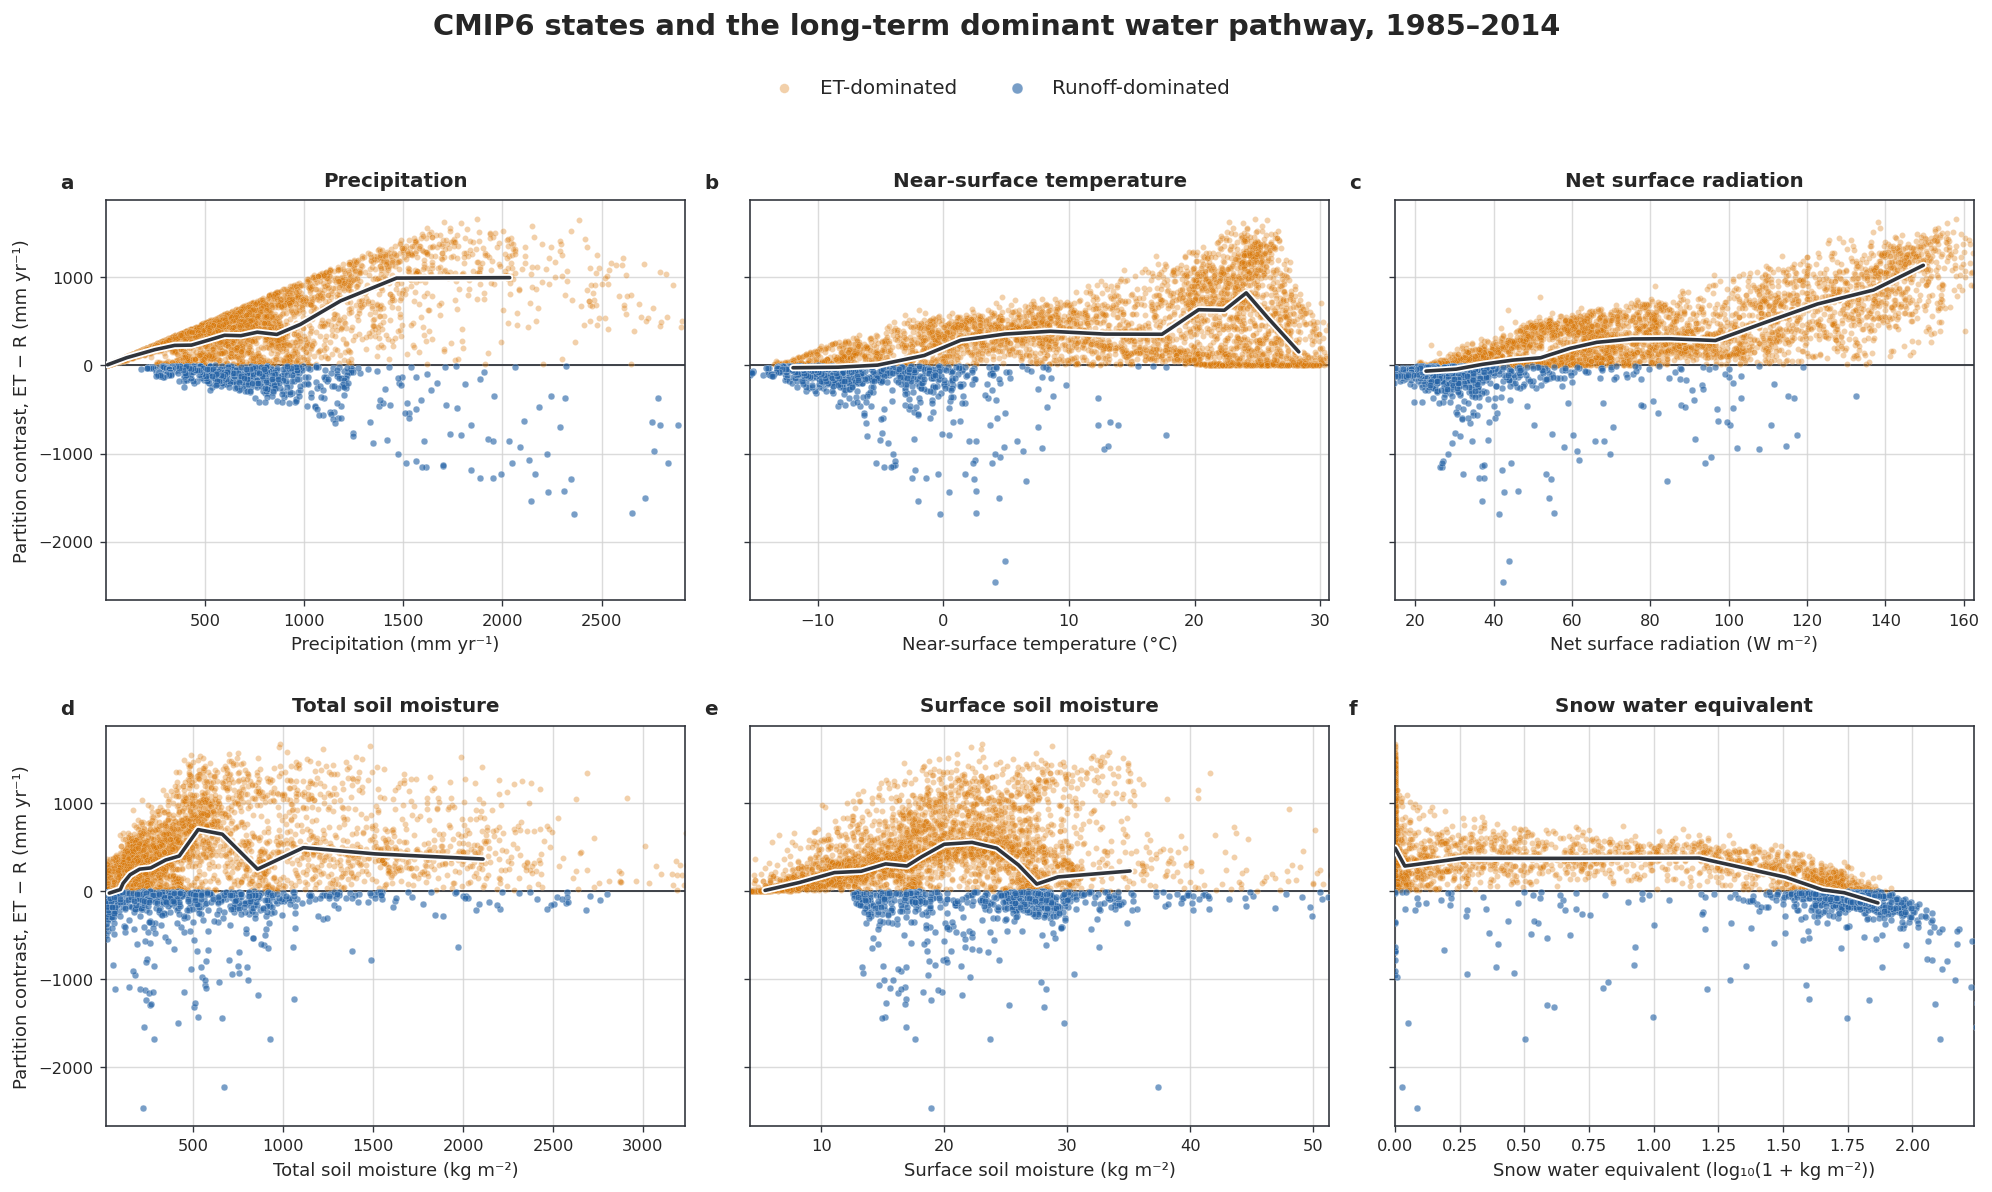

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/figures_step7/predictors_vs_partition_contrast.png


In [3]:
PREDICTOR_SPECS = [
    ("P", "Precipitation", "mm yr⁻¹"),
    ("tas_C", "Near-surface temperature", "°C"),
    ("net_radiation", "Net surface radiation", "W m⁻²"),
    ("mrso", "Total soil moisture", "kg m⁻²"),
    ("mrsos", "Surface soil moisture", "kg m⁻²"),
    ("log1p_snw", "Snow water equivalent", "log₁₀(1 + kg m⁻²)"),
]

def quantile_median_curve(frame, x, y="partition_contrast", bins=14):
    work = frame[[x, y]].dropna().copy()
    work["bin"] = pd.qcut(work[x], q=min(bins, work[x].nunique()), duplicates="drop")
    return work.groupby("bin", observed=True)[[x, y]].median()

fig, axes = plt.subplots(2, 3, figsize=(15.5, 9.2), sharey=True)
for panel, (ax, (column, label, unit)) in enumerate(zip(axes.flat, PREDICTOR_SPECS)):
    for regime in REGIME_ORDER:
        subset = data[data["regime"] == regime]
        ax.scatter(
            subset[column], subset["partition_contrast"],
            s=11 if regime == "ET-dominated" else 14,
            alpha=0.34 if regime == "ET-dominated" else 0.62,
            color=REGIME_COLORS[regime], edgecolors="white", linewidths=0.20,
            rasterized=True, zorder=2 if regime == "ET-dominated" else 3, label=regime,
        )
    curve = quantile_median_curve(data, column)
    ax.plot(curve[column], curve["partition_contrast"], color="white", linewidth=4.0, zorder=4)
    ax.plot(curve[column], curve["partition_contrast"], color="#30343B", linewidth=2.0, zorder=5)
    ax.axhline(0, color="#30343B", linewidth=1.0, zorder=1)
    ax.set_xlim(np.nanpercentile(data[column], [0.3, 99.7]))
    ax.set_xlabel(f"{label} ({unit})")
    ax.set_title(label, pad=8)
    ax.text(-0.08, 1.03, chr(97 + panel), transform=ax.transAxes, fontsize=11, fontweight="bold")
    style_axes(ax)
for ax in axes[:, 0]:
    ax.set_ylabel("Partition contrast, ET − R (mm yr⁻¹)")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles[:2], labels[:2], loc="upper center", bbox_to_anchor=(0.5, 0.955), ncol=2, frameon=False, markerscale=1.6)
fig.suptitle("CMIP6 states and the long-term dominant water pathway, 1985–2014", fontsize=16, fontweight="bold", y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.925], h_pad=2.0, w_pad=1.2)
path = FIGURE_DIR / "predictors_vs_partition_contrast.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print(f"Saved: {path}")

## 3. Selected two-variable combinations / 选择若干二维变量组合

**English.** A tree separates observations using combinations of thresholds, so two-variable views can reveal interactions that one-predictor plots miss. These panels are exploratory and do not imply causal effects. The runoff-dominated minority is plotted last so that it remains visible.

**中文。** Tree 通过多个变量阈值的组合划分样本，因此二维变量图可以显示单变量图遗漏的交互结构。这些面板只用于探索，不能解释为因果效应。径流主导网格属于少数，因此最后绘制以保证可见。

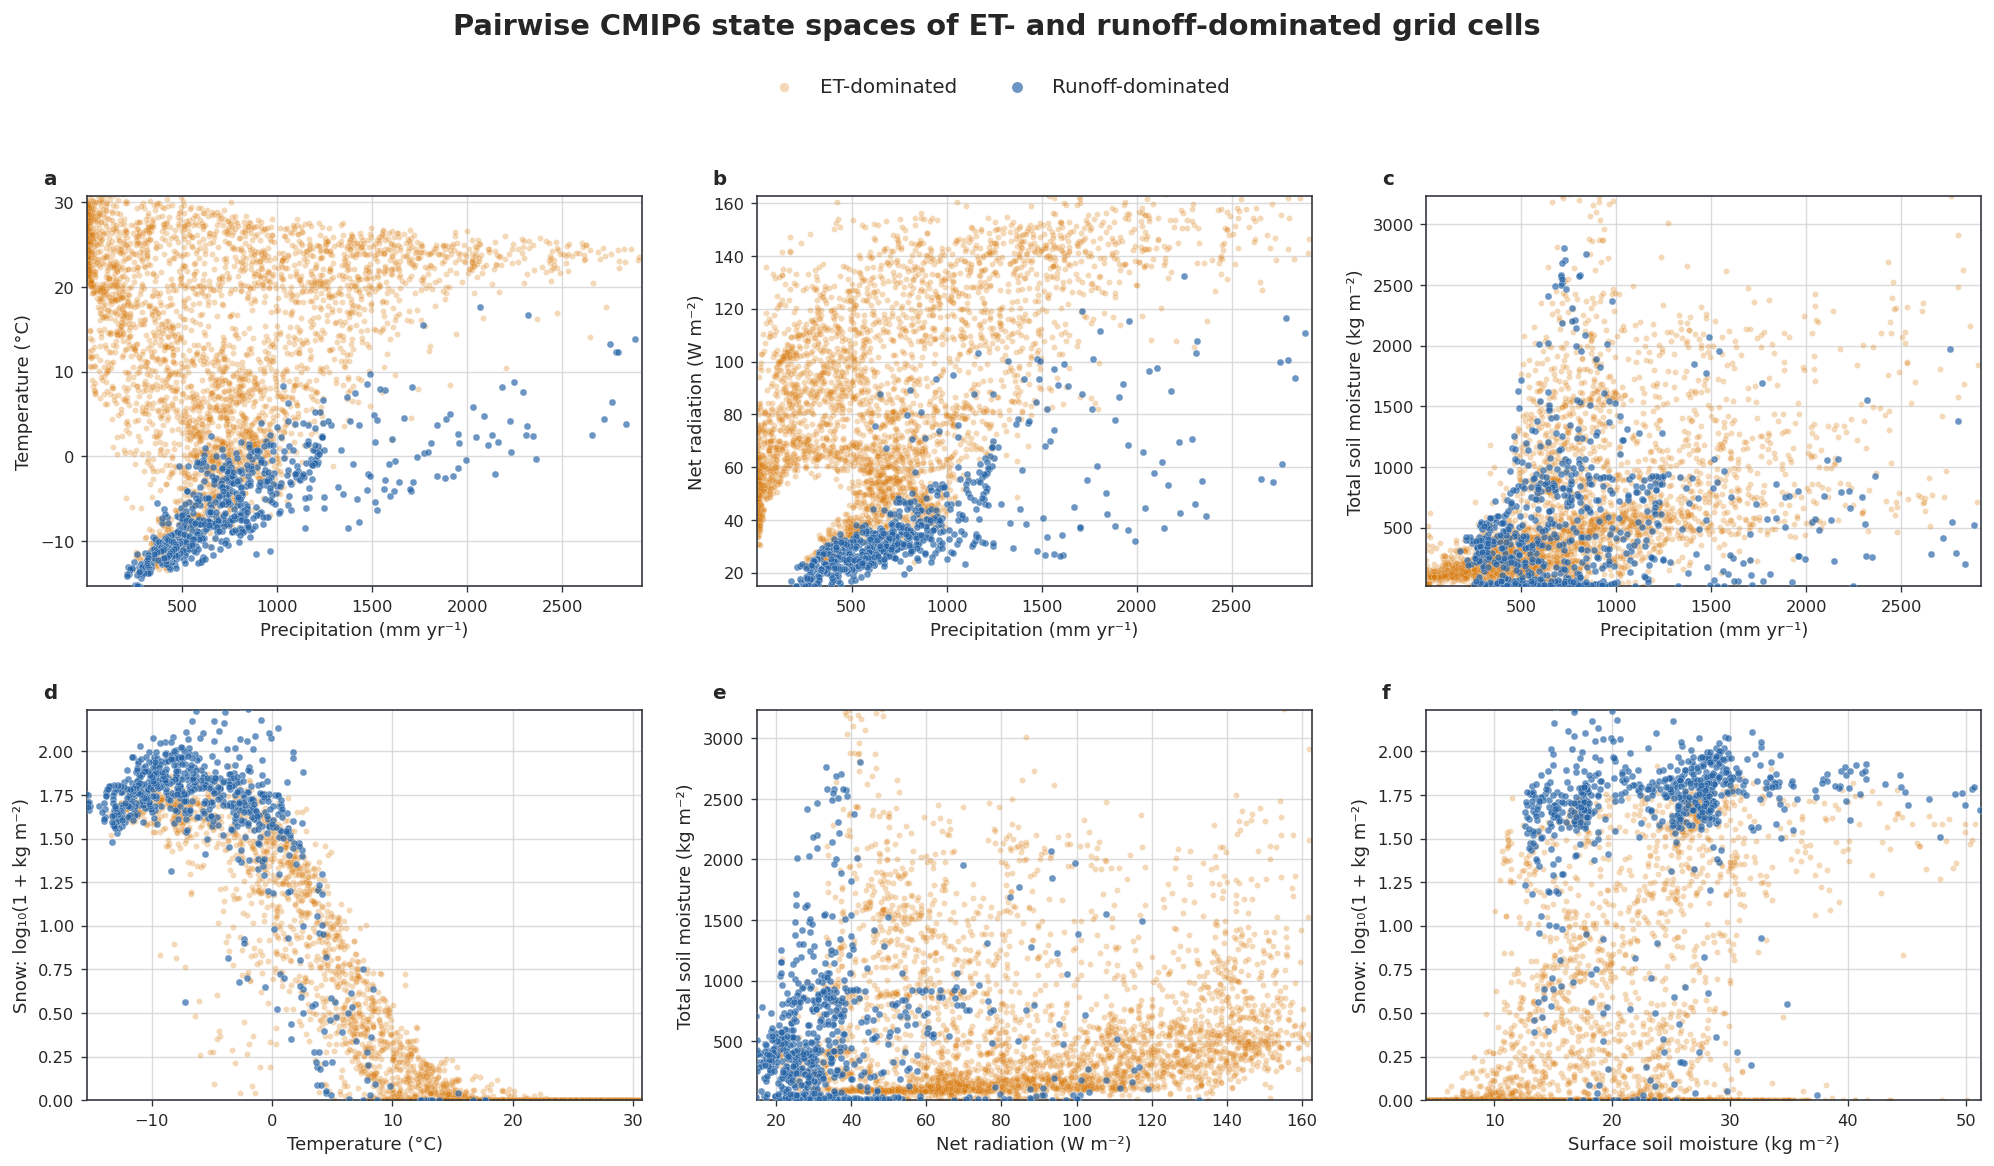

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/figures_step7/predictor_pairs_by_water_pathway_regime.png


In [4]:
PAIR_SPECS = [
    ("P", "tas_C", "Precipitation (mm yr⁻¹)", "Temperature (°C)"),
    ("P", "net_radiation", "Precipitation (mm yr⁻¹)", "Net radiation (W m⁻²)"),
    ("P", "mrso", "Precipitation (mm yr⁻¹)", "Total soil moisture (kg m⁻²)"),
    ("tas_C", "log1p_snw", "Temperature (°C)", "Snow: log₁₀(1 + kg m⁻²)"),
    ("net_radiation", "mrso", "Net radiation (W m⁻²)", "Total soil moisture (kg m⁻²)"),
    ("mrsos", "log1p_snw", "Surface soil moisture (kg m⁻²)", "Snow: log₁₀(1 + kg m⁻²)"),
]

fig, axes = plt.subplots(2, 3, figsize=(15.5, 9.0))
for panel, (ax, (x, y, xlabel, ylabel)) in enumerate(zip(axes.flat, PAIR_SPECS)):
    for regime in REGIME_ORDER:
        subset = data[data["regime"] == regime]
        ax.scatter(
            subset[x], subset[y],
            s=11 if regime == "ET-dominated" else 15,
            alpha=0.28 if regime == "ET-dominated" else 0.68,
            color=REGIME_COLORS[regime], edgecolors="white", linewidths=0.22,
            rasterized=True, zorder=2 if regime == "ET-dominated" else 3, label=regime,
        )
    ax.set_xlim(np.nanpercentile(data[x], [0.3, 99.7]))
    ax.set_ylim(np.nanpercentile(data[y], [0.3, 99.7]))
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.text(-0.08, 1.03, chr(97 + panel), transform=ax.transAxes, fontsize=11, fontweight="bold")
    style_axes(ax)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles[:2], labels[:2], loc="upper center", bbox_to_anchor=(0.5, 0.955), ncol=2, frameon=False, markerscale=1.6)
fig.suptitle("Pairwise CMIP6 state spaces of ET- and runoff-dominated grid cells", fontsize=16, fontweight="bold", y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.925], h_pad=2.0, w_pad=1.5)
path = FIGURE_DIR / "predictor_pairs_by_water_pathway_regime.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print(f"Saved: {path}")

## 4. Six CMIP6 variables versus runoff fraction / 六个 CMIP6 变量与径流比例

**English.** The target is the ratio of the 1985–2014 mean runoff to the 1985–2014 mean precipitation, $\overline{R}/\overline{P}$. Points are deliberately not colored by the ET/runoff-dominated class because that class is itself closely related to the runoff fraction. The curve connects medians in predictor quantile bins. The annotation is an area-weighted Spearman correlation.

**中文。** 目标变量是 1985–2014 平均径流与平均降水之比 $\overline{R}/\overline{P}$。这里不再按照蒸散/径流主导类别着色，因为该类别本身与径流比例密切相关，按类别着色会产生循环展示。曲线连接解释变量分位数分箱后的中位数，标注为面积加权 Spearman 相关。P 同时位于 $R/P$ 的分母，因此 P 面板只作描述，不能直接解释为因果关系。

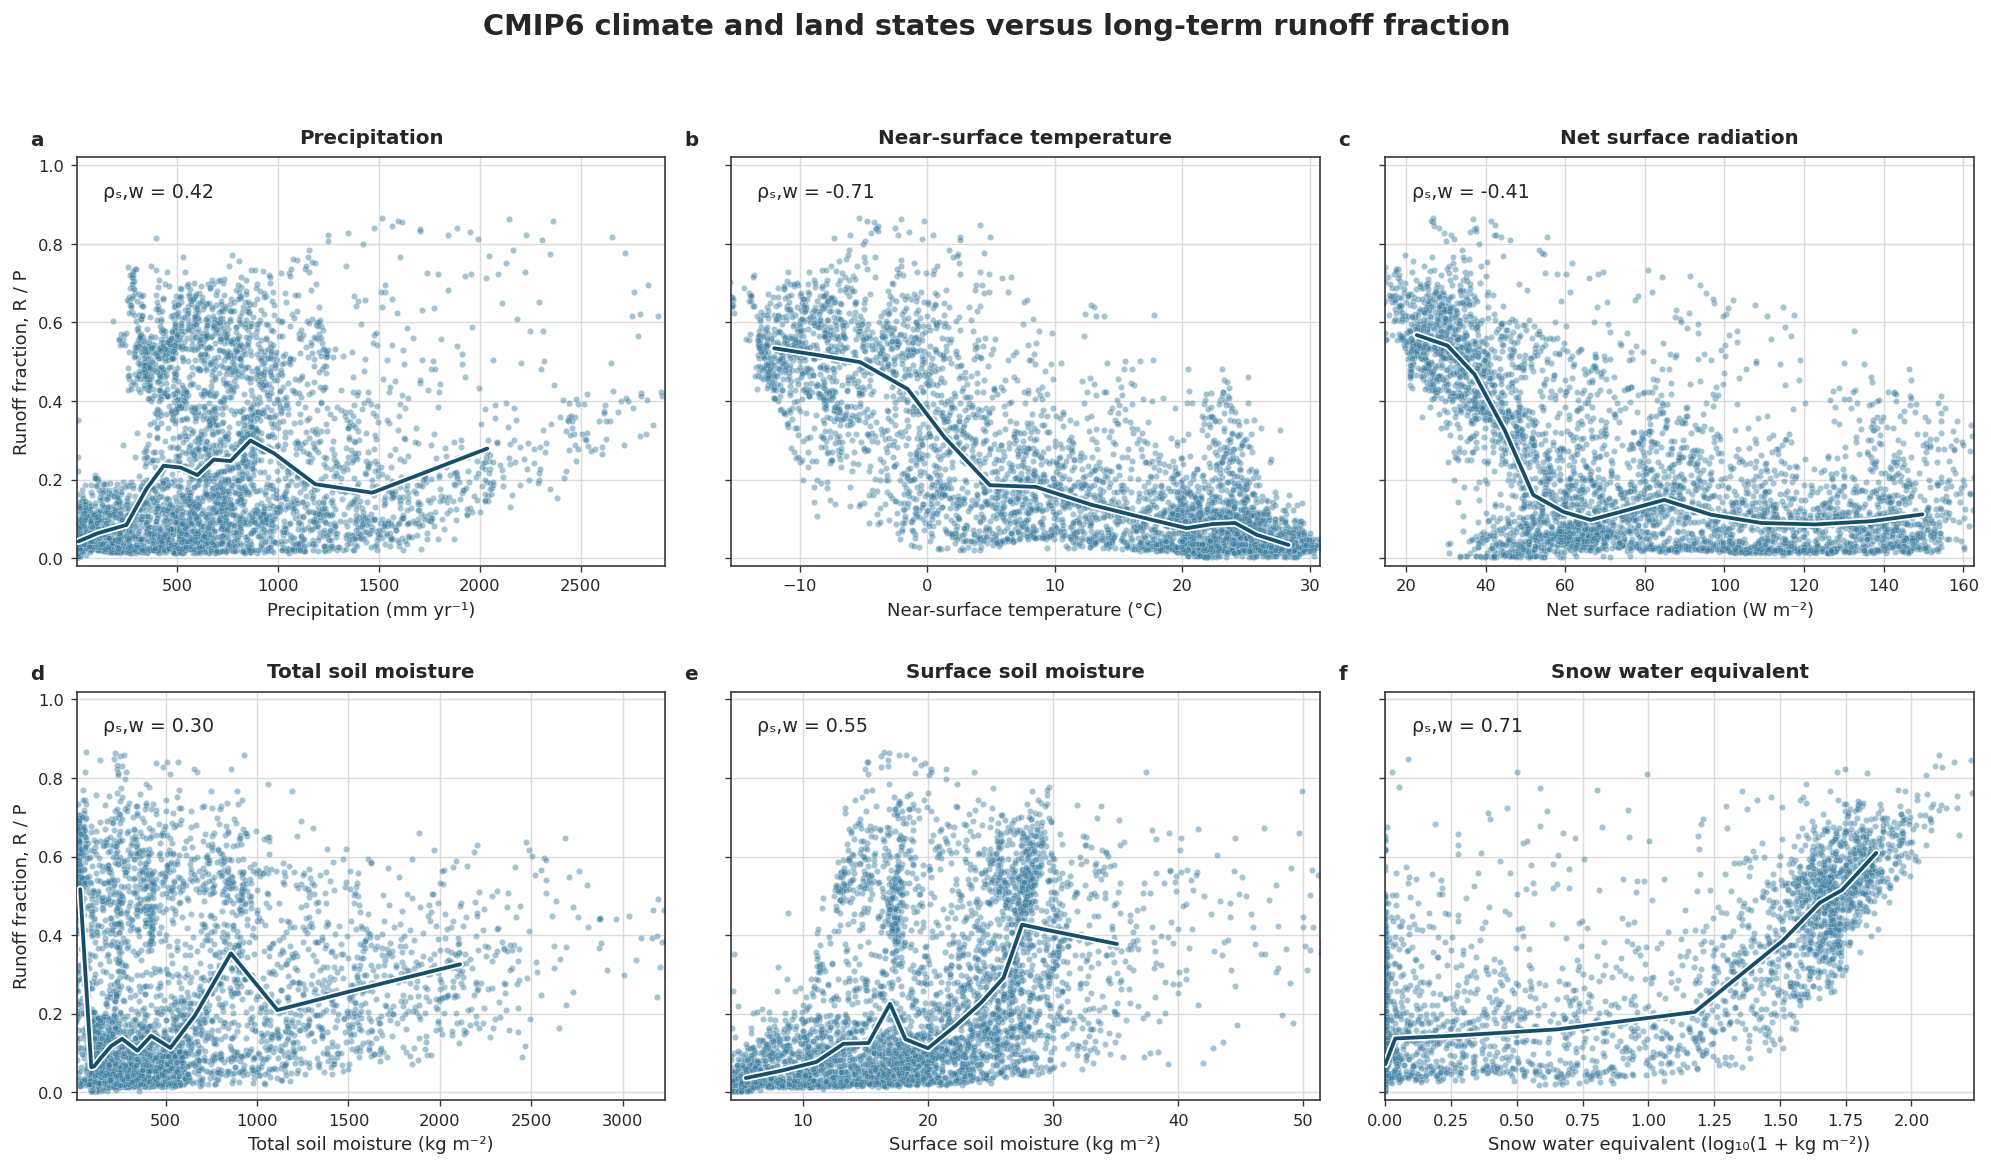

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/figures_step7/predictors_vs_runoff_fraction.png


In [5]:
def weighted_corr(x, y, w):
    x, y, w = map(np.asarray, (x, y, w))
    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)
    x, y, w = x[valid], y[valid], w[valid]
    w = w / w.sum()
    dx, dy = x - np.sum(w * x), y - np.sum(w * y)
    denom = np.sqrt(np.sum(w * dx * dx) * np.sum(w * dy * dy))
    return np.sum(w * dx * dy) / denom if denom > 0 else np.nan

def weighted_spearman(x, y, w):
    rx = pd.Series(x).rank(method="average").to_numpy()
    ry = pd.Series(y).rank(method="average").to_numpy()
    return weighted_corr(rx, ry, w)

fig, axes = plt.subplots(2, 3, figsize=(15.5, 9.0), sharey=True)
for panel, (ax, (column, label, unit)) in enumerate(zip(axes.flat, PREDICTOR_SPECS)):
    ax.scatter(
        data[column], data["R_fraction_climatology"],
        s=12, alpha=0.46, color="#397C9F", edgecolors="white", linewidths=0.22,
        rasterized=True, zorder=2,
    )
    curve = quantile_median_curve(data, column, y="R_fraction_climatology", bins=14)
    ax.plot(curve[column], curve["R_fraction_climatology"], color="white", linewidth=4.0, zorder=3)
    ax.plot(curve[column], curve["R_fraction_climatology"], color="#174F6B", linewidth=2.1, zorder=4)
    rho = weighted_spearman(data[column], data["R_fraction_climatology"], data["land_area"])
    ax.text(0.045, 0.94, f"ρₛ,w = {rho:.2f}", transform=ax.transAxes, va="top", fontsize=10.5)
    ax.set_xlim(np.nanpercentile(data[column], [0.3, 99.7]))
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel(f"{label} ({unit})")
    ax.set_title(label, pad=8)
    ax.text(-0.08, 1.03, chr(97 + panel), transform=ax.transAxes, fontsize=11, fontweight="bold")
    style_axes(ax)
for ax in axes[:, 0]:
    ax.set_ylabel("Runoff fraction, R / P")
fig.suptitle("CMIP6 climate and land states versus long-term runoff fraction", fontsize=16, fontweight="bold", y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.96], h_pad=2.0, w_pad=1.2)
path = FIGURE_DIR / "predictors_vs_runoff_fraction.png"
fig.savefig(path, bbox_inches="tight")
plt.show()
print(f"Saved: {path}")

## 5. Pairwise state spaces within four climate zones / 四个气候区内部的二维变量关系

**English.** The global pair plots mix fundamentally different hydroclimatic backgrounds. Each figure below therefore holds one CMIP6 variable pair fixed and compares WW, WD, CW, and CD in a 1×4 layout. Axis limits are identical across the four panels. Colors show the ET- and runoff-dominated outcome. Köppen-based zones are used only as stratification labels; all plotted predictors and outcomes remain CMIP6 variables.

**中文。** 全球二维图会把不同水热背景混在一起。下面每张图固定一组 CMIP6 变量 pairing，并用 1×4 面板比较 WW、WD、CW、CD。四个面板使用完全相同的坐标范围，颜色表示蒸散主导或径流主导。Köppen 代理区只作为分层标签，图中的输入变量和输出状态仍全部来自 CMIP6。

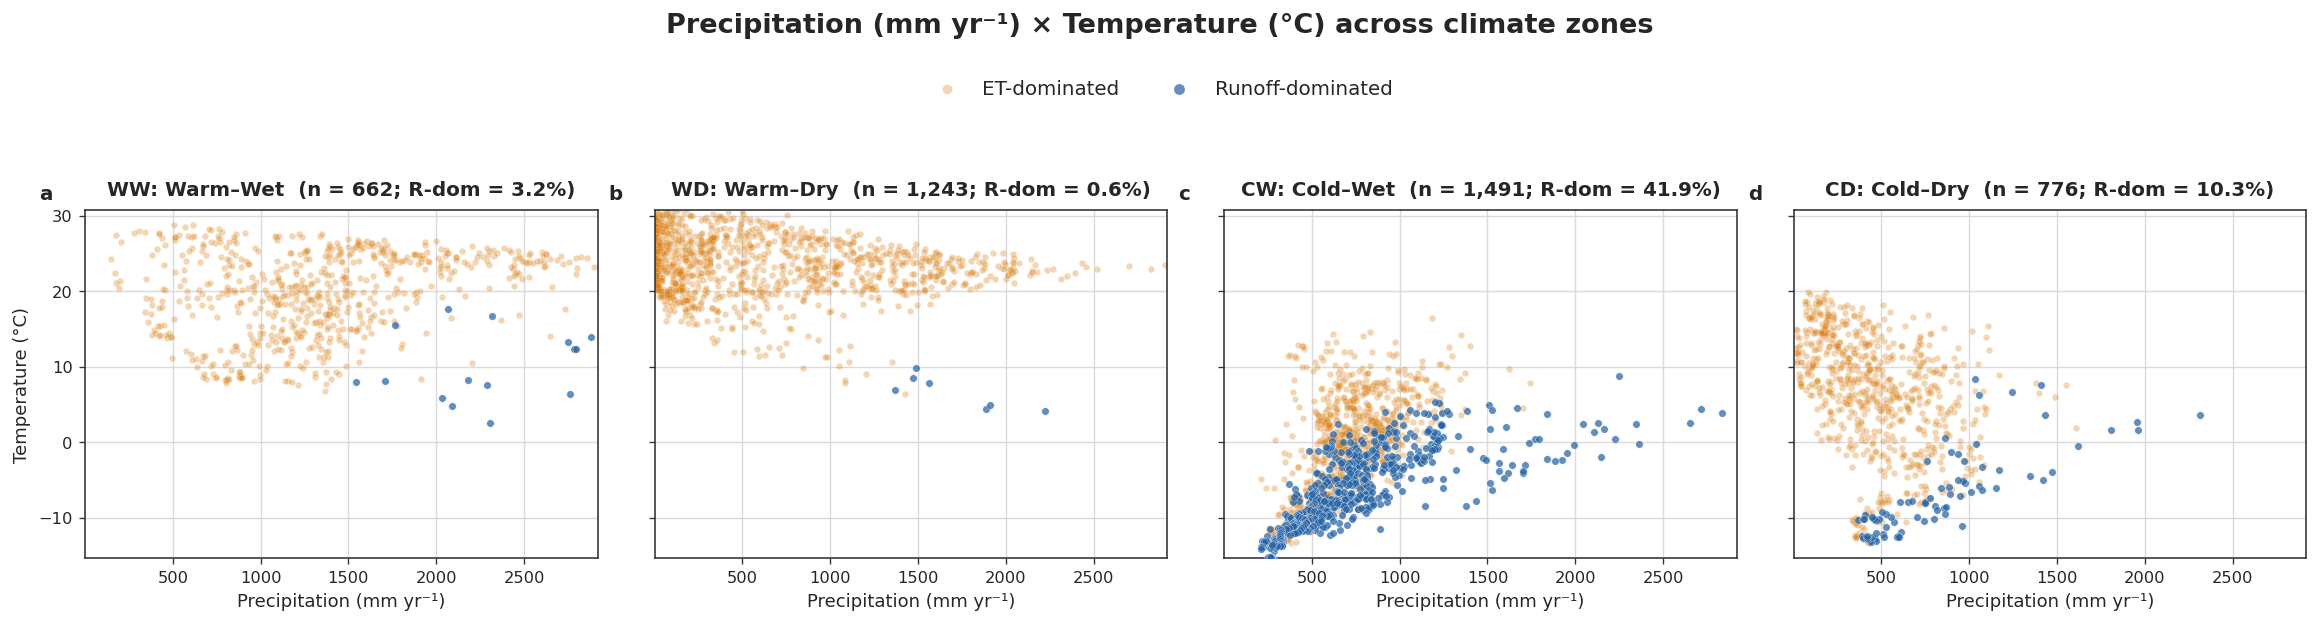

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/figures_step7/P_temperature_by_zone.png


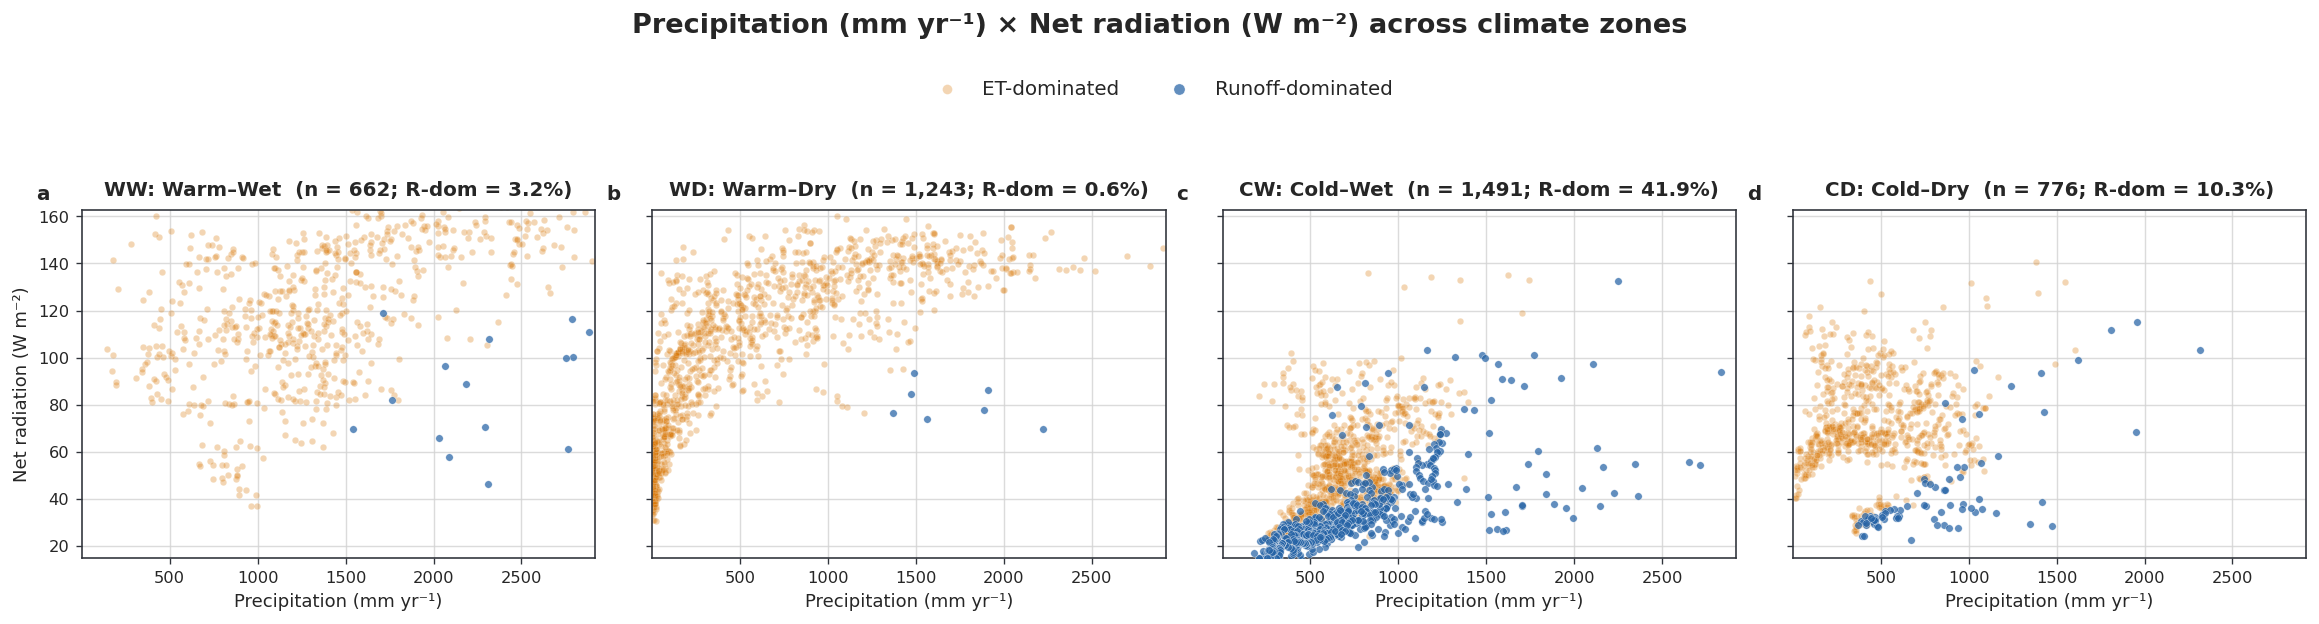

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/figures_step7/P_net_radiation_by_zone.png


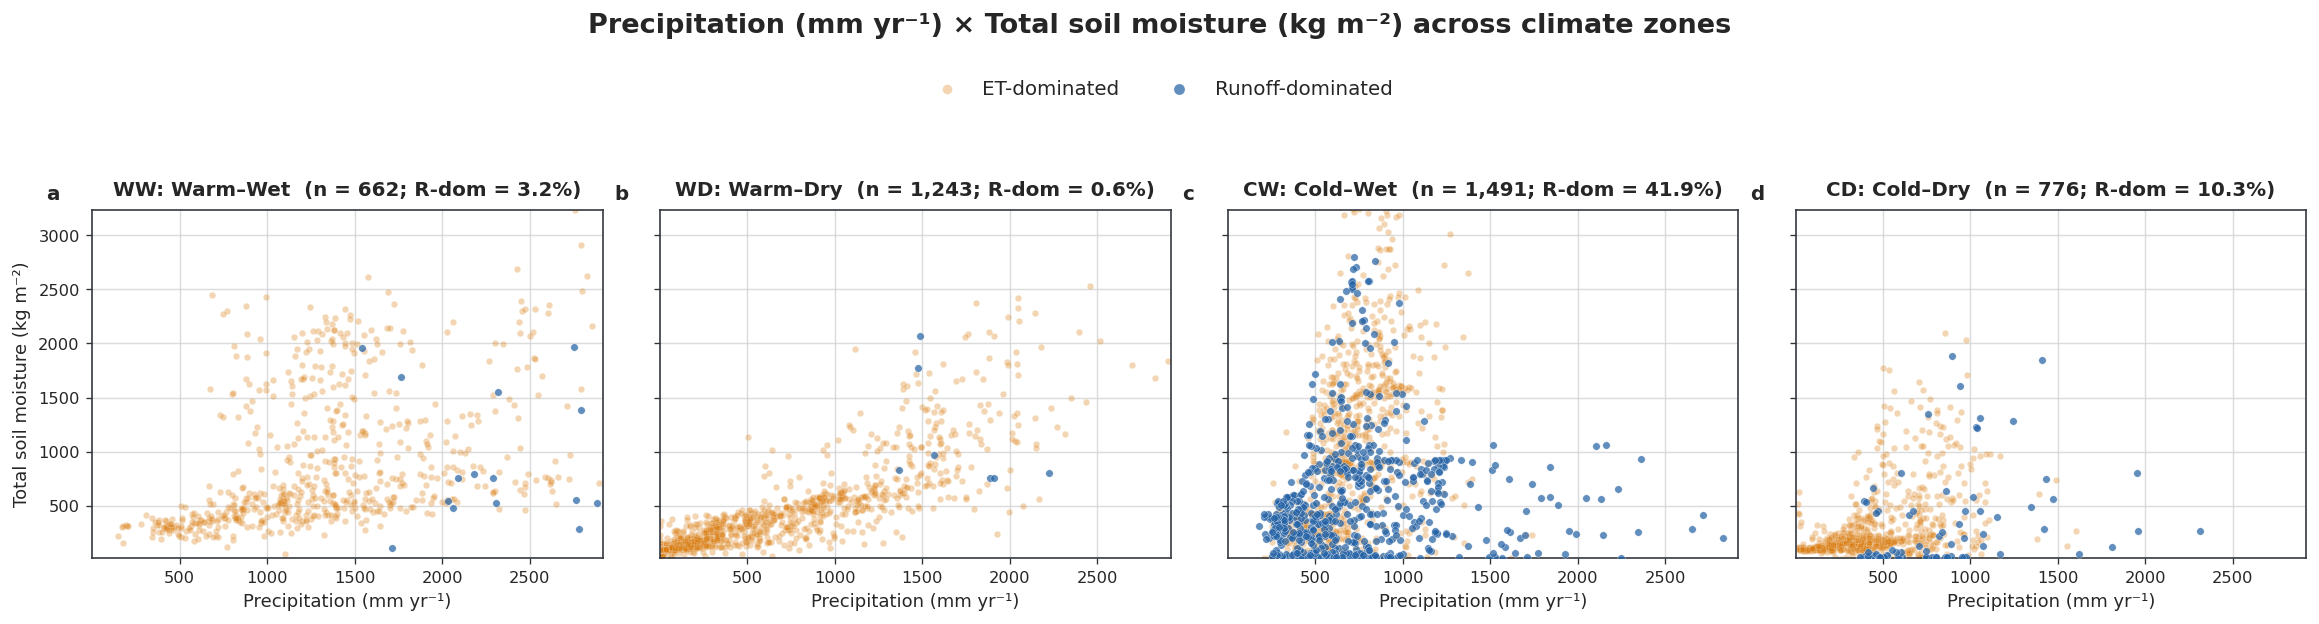

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/figures_step7/P_total_soil_moisture_by_zone.png


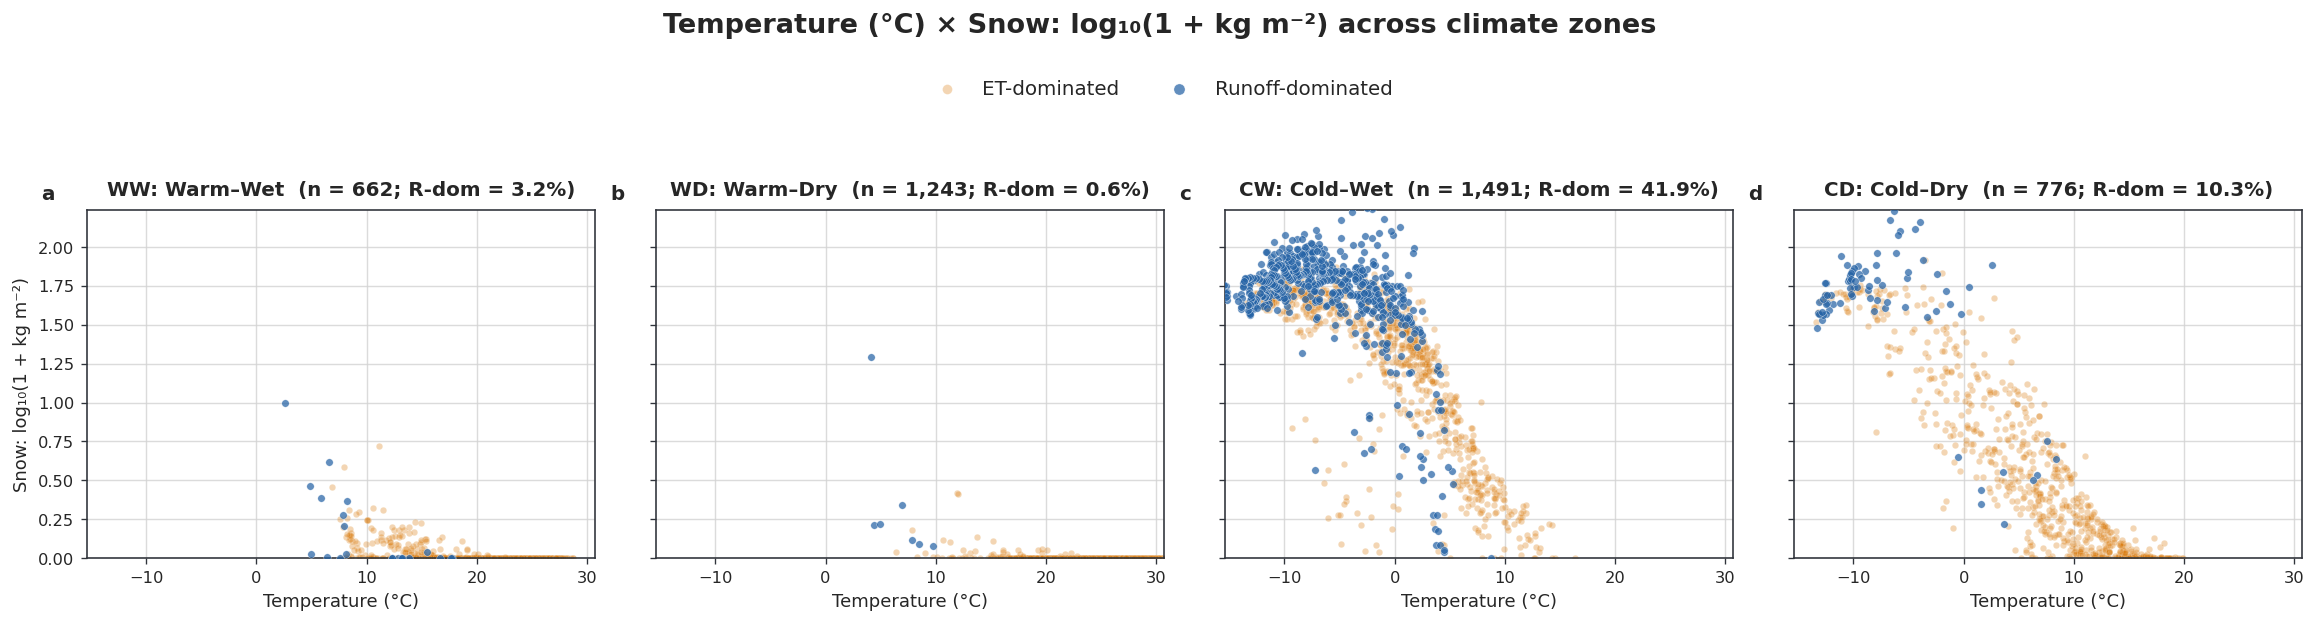

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/figures_step7/temperature_snow_by_zone.png


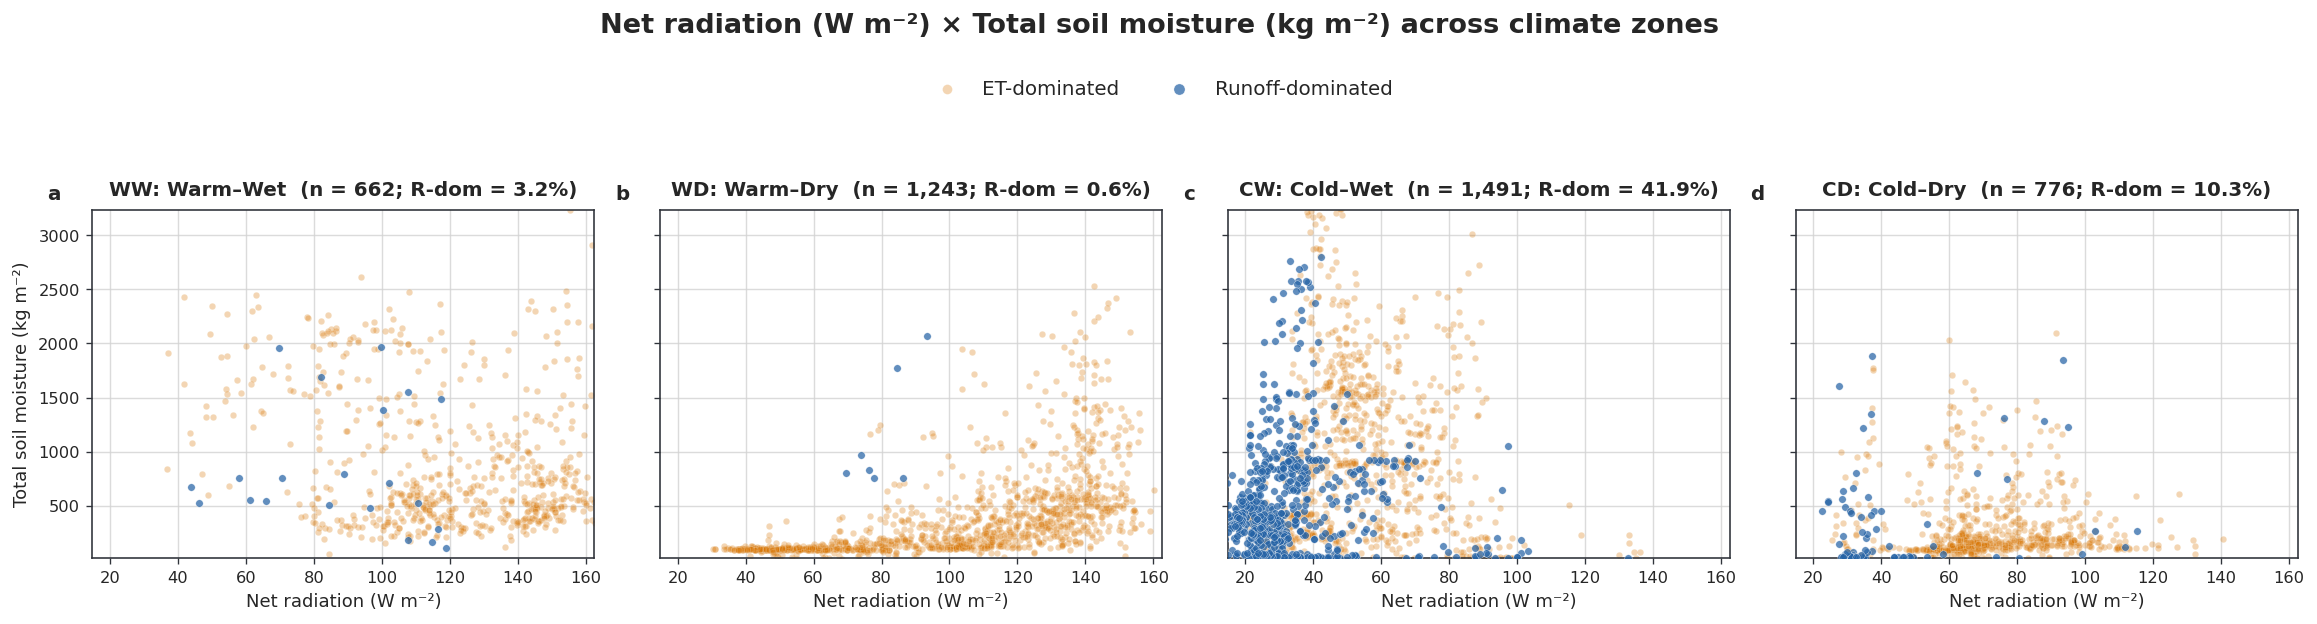

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/figures_step7/net_radiation_total_soil_moisture_by_zone.png


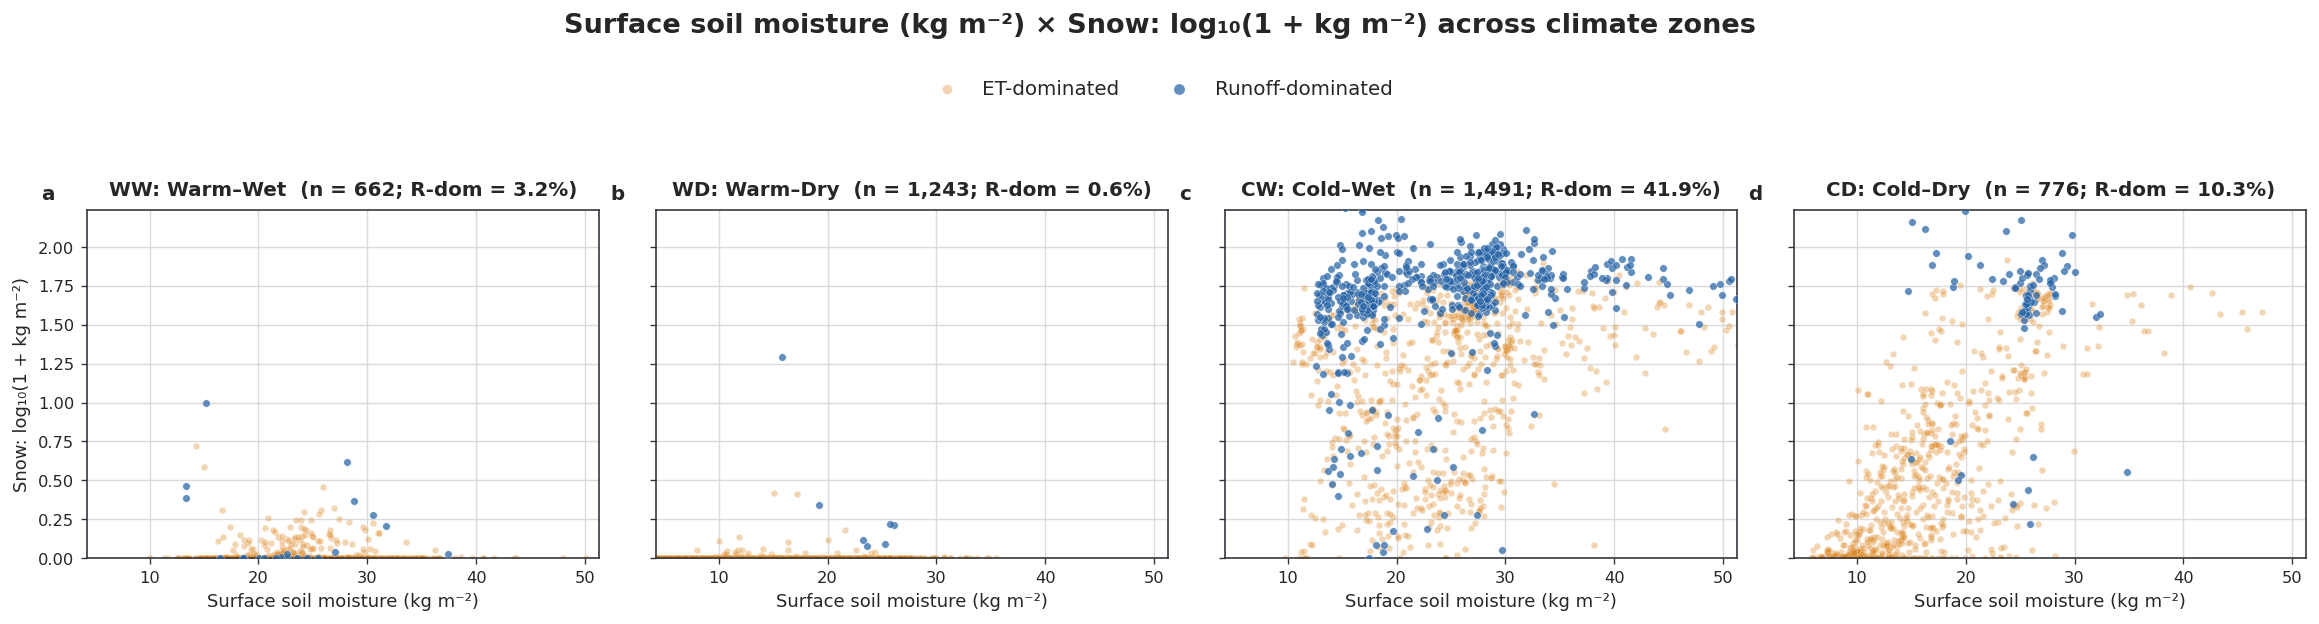

Saved: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA/derived/figures_step7/surface_soil_moisture_snow_by_zone.png


In [6]:
ZONE_ORDER = ["WW", "WD", "CW", "CD"]
ZONE_LABELS = {"WW": "Warm–Wet", "WD": "Warm–Dry", "CW": "Cold–Wet", "CD": "Cold–Dry"}
ZONE_PAIR_SPECS = [
    ("P", "tas_C", "Precipitation (mm yr⁻¹)", "Temperature (°C)", "P_temperature_by_zone.png"),
    ("P", "net_radiation", "Precipitation (mm yr⁻¹)", "Net radiation (W m⁻²)", "P_net_radiation_by_zone.png"),
    ("P", "mrso", "Precipitation (mm yr⁻¹)", "Total soil moisture (kg m⁻²)", "P_total_soil_moisture_by_zone.png"),
    ("tas_C", "log1p_snw", "Temperature (°C)", "Snow: log₁₀(1 + kg m⁻²)", "temperature_snow_by_zone.png"),
    ("net_radiation", "mrso", "Net radiation (W m⁻²)", "Total soil moisture (kg m⁻²)", "net_radiation_total_soil_moisture_by_zone.png"),
    ("mrsos", "log1p_snw", "Surface soil moisture (kg m⁻²)", "Snow: log₁₀(1 + kg m⁻²)", "surface_soil_moisture_snow_by_zone.png"),
]

def plot_pair_by_zone(x, y, xlabel, ylabel, filename):
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.45), sharex=True, sharey=True)
    xlim = np.nanpercentile(data[x], [0.3, 99.7])
    ylim = np.nanpercentile(data[y], [0.3, 99.7])
    for panel, (ax, zone) in enumerate(zip(axes, ZONE_ORDER)):
        zone_data = data[data["zone"] == zone]
        for regime in REGIME_ORDER:
            subset = zone_data[zone_data["regime"] == regime]
            ax.scatter(
                subset[x], subset[y],
                s=13 if regime == "ET-dominated" else 17,
                alpha=0.30 if regime == "ET-dominated" else 0.72,
                color=REGIME_COLORS[regime], edgecolors="white", linewidths=0.24,
                rasterized=True, zorder=2 if regime == "ET-dominated" else 3, label=regime,
            )
        runoff_share = (zone_data["regime"] == "Runoff-dominated").mean()
        ax.set_title(f"{zone}: {ZONE_LABELS[zone]}  (n = {len(zone_data):,}; R-dom = {runoff_share:.1%})", pad=8)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_xlabel(xlabel)
        ax.text(-0.09, 1.03, chr(97 + panel), transform=ax.transAxes, fontsize=11, fontweight="bold")
        style_axes(ax)
    axes[0].set_ylabel(ylabel)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles[:2], labels[:2], loc="upper center", bbox_to_anchor=(0.5, 0.99), ncol=2, frameon=False, markerscale=1.5)
    fig.suptitle(f"{xlabel} × {ylabel} across climate zones", fontsize=15, fontweight="bold", y=1.075)
    fig.tight_layout(rect=[0, 0, 1, 0.91], w_pad=1.0)
    path = FIGURE_DIR / filename
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")

for spec in ZONE_PAIR_SPECS:
    plot_pair_by_zone(*spec)

## 6. Reading these figures / 如何阅读这些图

**English.** The purpose is to identify plausible variables and interactions for a later shallow tree. Separation in a scatterplot is evidence that a variable combination characterizes the two simulated regimes; it is not evidence that the variables independently cause the partition. Soil moisture and snow are internal ESM states and may be responses as well as controls.

**中文。** 这些图用于筛选后续浅层 tree 值得使用的变量和交互。如果两类点在某个二维空间中明显分开，只能说明该变量组合能够刻画两种模拟状态，不能证明变量独立地造成了水量分配。土壤水分和积雪都是 ESM 内部状态，既可能影响 ET 和径流，也可能是水循环过程的结果。